# Occupancy-weighted prior effect, and convergence across models

Two things, following the review.

**1. A continuous HMM measure, replacing threshold-defined occupancy.** Figure 4e selects the states
that show a colour effect *within a group*, then summarises occupancy of exactly those states. That is
circular, and it produces the zero-variance conditions flagged in Table 2 (groups where no state
reaches significance get occupancy 0 for every session by construction).

The continuous alternative needs no thresholding. For each session,

$$\text{prior effect} = \sum_k \text{occupancy}_k \times w_{\text{colour},k}$$

the occupancy-weighted average of the state colour weights. It is one number per session, in
log-odds, on the same scale as the mixed model's colour effect, so it also feeds part 2.

**2. Do the three models agree at the level of individual participants?** If the mixed model, the
GLM-HMM and the DDM describe the same thing, the participants whose prior use changes most with
medication in one should be the same in the others.

Outputs go to the gitignored `outputs/` directory.


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
import pickle
from scipy.optimize import linear_sum_assignment

from config import dir_config, main_config
from src.shared_glm_hmm.fitting import session_arrays
from src.shared_glm_hmm.grouping import session_metadata

processed_dir = Path(dir_config.data.processed)
metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
ddm_params = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60_ddm_params.csv")

OUTPUT_DIR = (Path.cwd().parent / "outputs").resolve()
assert not str(OUTPUT_DIR).startswith(str(processed_dir.parents[0]))
OUTPUT_DIR.mkdir(exist_ok=True)

SELECTED_MODEL = main_config.GLM_HMM.final_model
bundle = pickle.load(open(processed_dir / "shared_glm_hmm" / SELECTED_MODEL / "all_subjects_final.pkl", "rb"))
features = bundle["config"]["model_features"]
COLOUR, STIMULUS = features.index("color"), features.index("stimulus")
print(f"model {SELECTED_MODEL}, K = {bundle['best_k']}, features {features}")


model XY__tgt, K = 4, features ['stimulus', 'color', 'bias', 'prev_choice_1', 'prev_target_1', 'prev_choice_target_1']


## Part 1. Occupancy-weighted prior effect

Weights are sign-flipped to express the log-odds of a positive choice, and each session's states are
Hungarian-aligned to the pooled reference, exactly as in `4.10`.


In [3]:
def align(weights, reference):
    cost = ((weights[:, None, :] - reference[None, :, :]) ** 2).sum(-1)
    _, col = linear_sum_assignment(cost)
    inverse = np.empty_like(col); inverse[col] = np.arange(len(col))
    return inverse


reference = -bundle["model"]["pooled"].observations.params[:, 0, :]
observations, inputs, masks = session_arrays(bundle)
sessions = list(bundle["data"].keys())

rows = []
for i, session in enumerate(sessions):
    model = bundle["model"]["models"][session]
    weights = -model.observations.params[:, 0, :]
    order = align(weights, reference)
    posterior = model.expected_states(data=observations[i], input=inputs[i], mask=masks[i])[0]
    valid = masks[i][:, 0]
    occupancy = posterior[:, order][valid].mean(0)
    aligned = weights[order]
    rows.append({"session_id": session,
                 "prior_effect": float(occupancy @ aligned[:, COLOUR]),
                 "stimulus_weight": float(occupancy @ aligned[:, STIMULUS]),
                 **{f"occ_state{k + 1}": float(occupancy[k]) for k in range(len(occupancy))}})

hmm = pd.DataFrame(rows).merge(session_metadata(metadata), on="session_id", how="left")
hmm["group"] = np.where(hmm["is_pd"] == 0, "HC", hmm["subtype"] + "_" + hmm["medication"])
print(f"{len(hmm)} sessions")
hmm.groupby("group")[["prior_effect", "stimulus_weight"]].agg(["mean", "sem", "count"]).round(3)


100 sessions


prior_effect              stimulus_weight             
                         mean    sem count            mean    sem count
group                                                                  
HC                      0.448  0.153    18           4.302  0.392    18
bradykinetic_off        0.224  0.190    10           3.540  0.201    10
bradykinetic_on         0.237  0.192    10           3.488  0.367    10
intermediate_off        1.537    NaN     1           5.543    NaN     1
intermediate_on        -0.378    NaN     1           4.910    NaN     1
tremor_off              0.063  0.208    11           4.976  0.967    11
tremor_on               0.650  0.193    11           4.214  0.643    11

### Paired OFF to ON change, and the group comparisons


In [4]:
ORDER = ["HC", "tremor_off", "tremor_on", "bradykinetic_off", "bradykinetic_on"]
wide = (hmm[hmm["is_pd"] == 1]
        .pivot_table(index=["subject_id", "subtype"], columns="medication", values="prior_effect")
        .dropna().reset_index())
wide["change"] = wide["on"] - wide["off"]

tests = []
for subtype in ["tremor", "bradykinetic"]:
    block = wide[wide["subtype"] == subtype]
    stat, p = stats.wilcoxon(block["off"], block["on"])
    tests.append({"test": f"{subtype}: OFF vs ON (paired)", "n": len(block), "OFF": block['off'].mean(),
                  "ON": block["on"].mean(), "effect": block["change"].mean(),
                  "dz": block["change"].mean() / block["change"].std(), "p": p})

controls = hmm.loc[hmm["group"] == "HC", "prior_effect"]
for subtype in ["tremor", "bradykinetic"]:
    off = hmm.loc[hmm["group"] == f"{subtype}_off", "prior_effect"]
    u, p = stats.mannwhitneyu(controls, off)
    tests.append({"test": f"HC vs {subtype} OFF", "n": f"{len(controls)} v {len(off)}",
                  "OFF": off.mean(), "ON": np.nan, "effect": controls.mean() - off.mean(), "dz": np.nan, "p": p})

a = wide.loc[wide["subtype"] == "tremor", "change"]
b = wide.loc[wide["subtype"] == "bradykinetic", "change"]
u, p = stats.mannwhitneyu(a, b)
tests.append({"test": "tremor vs brady medication effect", "n": f"{len(a)} v {len(b)}", "OFF": np.nan,
              "ON": np.nan, "effect": a.mean() - b.mean(), "dz": np.nan, "p": p})

pd.DataFrame(tests).set_index("test").round(4)


,n,OFF,ON,effect,dz,p
test,,,,,,
tremor: OFF vs ON (paired),11,0.0628,0.6496,0.5868,0.5718,0.1016
bradykinetic: OFF vs ON (paired),10,0.2242,0.2373,0.0131,0.0154,1.0000
HC vs tremor OFF,18 v 11,0.0628,NaN,0.3847,NaN,0.1210
HC vs bradykinetic OFF,18 v 10,0.2242,NaN,0.2233,NaN,0.1572
tremor vs brady medication effect,11 v 10,NaN,NaN,0.5737,NaN,0.2453


### Figure. Continuous measure, paired


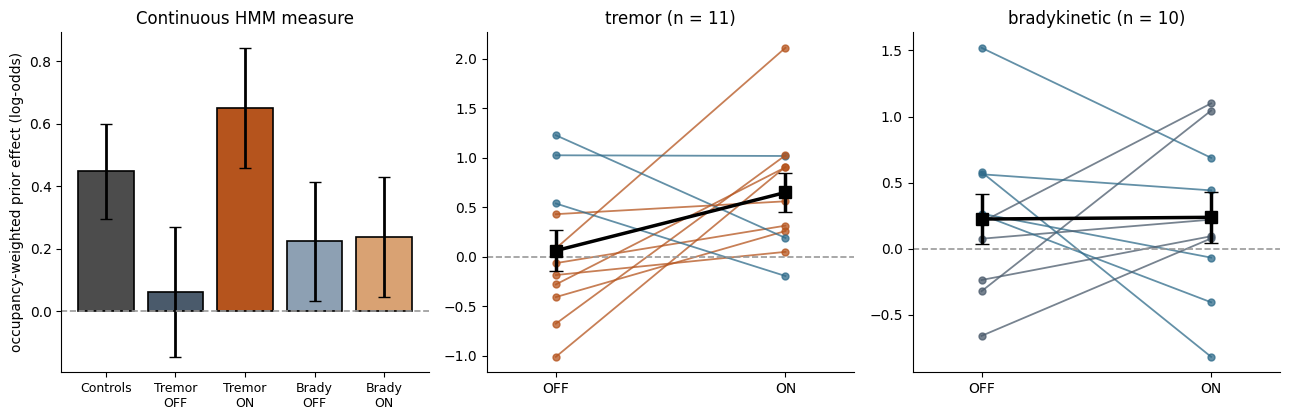

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
colors = {"HC": "#4C4C4C", "tremor": "#B5541D", "bradykinetic": "#4A5A6B"}

means = [hmm.loc[hmm["group"] == g, "prior_effect"] for g in ORDER]
axes[0].bar(range(5), [m.mean() for m in means], color=["#4C4C4C", "#4A5A6B", "#B5541D", "#8DA0B3", "#D9A273"],
            edgecolor="k", lw=1.2)
axes[0].errorbar(range(5), [m.mean() for m in means], yerr=[stats.sem(m) for m in means], ls="", color="k", capsize=4, lw=2)
axes[0].axhline(0, color="0.6", ls="--", lw=1.2)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(["Controls", "Tremor\nOFF", "Tremor\nON", "Brady\nOFF", "Brady\nON"], fontsize=9)
axes[0].set_ylabel("occupancy-weighted prior effect (log-odds)"); axes[0].set_title("Continuous HMM measure", fontsize=12)

for ax, subtype in zip(axes[1:], ["tremor", "bradykinetic"]):
    block = wide[wide["subtype"] == subtype]
    for _, r in block.iterrows():
        ax.plot([0, 1], [r["off"], r["on"]], "-o", ms=5, lw=1.3, alpha=0.75,
                color=colors[subtype] if r["change"] > 0 else "#2F6B8A")
    ax.errorbar([0, 1], [block["off"].mean(), block["on"].mean()],
                yerr=[stats.sem(block["off"]), stats.sem(block["on"])], color="k", marker="s", ms=9, lw=2.5, capsize=5, zorder=5)
    ax.axhline(0, color="0.6", ls="--", lw=1.2)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["OFF", "ON"]); ax.set_xlim(-0.3, 1.3)
    ax.set_title(f"{subtype} (n = {len(block)})", fontsize=12)

for ax in axes:
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "hmm_occupancy_weighted.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "hmm_occupancy_weighted.png", dpi=200, bbox_inches="tight"); plt.show()


## Part 2. Do the three models agree about individuals?

Three participant-level medication effects, all OFF-to-ON changes in how strongly the prior biases
choice:

| Source | Quantity |
|---|---|
| Mixed model | posterior mean of the participant's colour x medication effect (`2.26`) |
| GLM-HMM | change in the occupancy-weighted prior effect, from Part 1 |
| DDM | change in (unequal minus equal) drift-rate offset |

Correlations use Spearman, with percentile bootstrap 95% intervals over participants.


In [6]:
mixed = pd.read_csv(OUTPUT_DIR / "participant_medication_effects.csv").set_index("participant_id")[["subtype", "mean"]]
mixed = mixed.rename(columns={"mean": "mixed_model"})

ddm = ddm_params.assign(subject_id=metadata["subject_id"], treatment=metadata["treatment"])
ddm["shift"] = ddm["drift_offset_prior_cond_1"].astype(float) - ddm["drift_offset_prior_cond_0"].astype(float)
ddm_wide = ddm.dropna(subset=["treatment"]).pivot_table(index="subject_id", columns="treatment", values="shift")
ddm_change = (ddm_wide["ON"] - ddm_wide["OFF"]).rename("ddm")

hmm_change = wide.set_index("subject_id")["change"].rename("glm_hmm")

convergence = mixed.join(hmm_change).join(ddm_change).dropna()
print(f"{len(convergence)} participants with all three measures")
convergence.round(3)


21 participants with all three measures


,subtype,mixed_model,glm_hmm,ddm
participant_id,,,,
P11,tremor,0.385,0.378,-0.132
P19,tremor,0.295,0.234,0.001
P29,tremor,1.160,1.699,0.555
P6,tremor,1.732,1.917,2.924
P32,tremor,0.388,0.130,0.810
P31,tremor,-0.904,-1.036,-0.591
P12,tremor,0.864,1.182,0.247
P18,tremor,0.041,-0.007,-0.190
P3,tremor,0.465,0.666,0.864


In [7]:
def bootstrap_spearman(x, y, n_boot=10000, seed=0):
    rho = stats.spearmanr(x, y).statistic
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(x), len(x))
        if len(np.unique(x[idx])) < 3 or len(np.unique(y[idx])) < 3:
            continue
        draws.append(stats.spearmanr(x[idx], y[idx]).statistic)
    low, high = np.percentile(draws, [2.5, 97.5])
    return rho, low, high, stats.spearmanr(x, y).pvalue


pairs = [("mixed_model", "glm_hmm"), ("mixed_model", "ddm"), ("glm_hmm", "ddm")]
rows = []
for subset_label, block in [("all patients", convergence),
                            ("tremor", convergence[convergence["subtype"] == "tremor"]),
                            ("bradykinesia", convergence[convergence["subtype"] == "bradykinetic"])]:
    for a, b in pairs:
        rho, low, high, p = bootstrap_spearman(block[a].to_numpy(), block[b].to_numpy())
        rows.append({"sample": subset_label, "pair": f"{a} vs {b}", "n": len(block),
                     "rho": rho, "2.5%": low, "97.5%": high, "p": p})

convergence_tests = pd.DataFrame(rows).set_index(["sample", "pair"])
convergence_tests.round(3)


n    rho   2.5%  97.5%      p
sample       pair                                                  
all patients mixed_model vs glm_hmm  21  0.977  0.893  0.999  0.000
             mixed_model vs ddm      21  0.852  0.614  0.955  0.000
             glm_hmm vs ddm          21  0.826  0.545  0.940  0.000
tremor       mixed_model vs glm_hmm  11  0.964  0.767  1.000  0.000
             mixed_model vs ddm      11  0.918  0.604  1.000  0.000
             glm_hmm vs ddm          11  0.845  0.386  1.000  0.001
bradykinesia mixed_model vs glm_hmm  10  0.976  0.810  1.000  0.000
             mixed_model vs ddm      10  0.952  0.687  1.000  0.000
             glm_hmm vs ddm          10  0.927  0.620  1.000  0.000

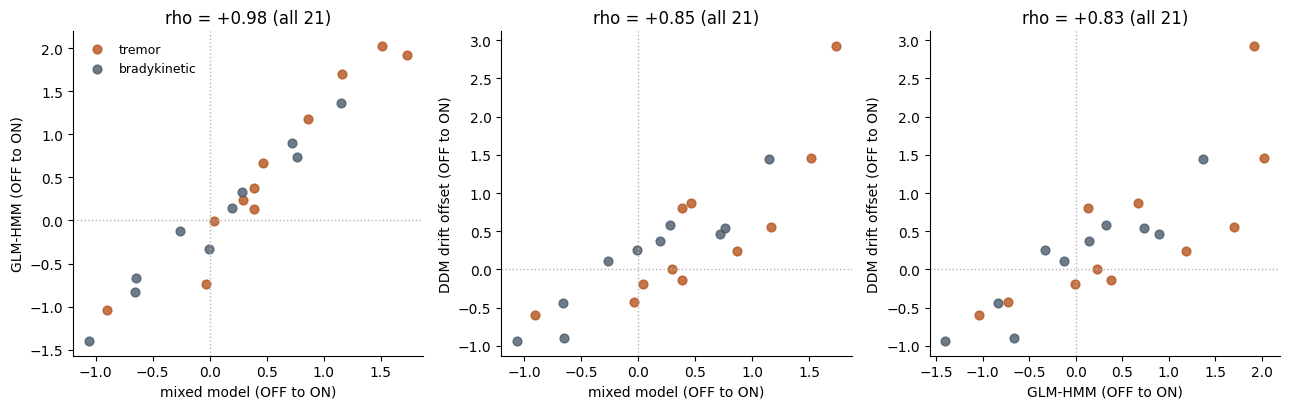

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
labels = {"mixed_model": "mixed model", "glm_hmm": "GLM-HMM", "ddm": "DDM drift offset"}
for ax, (a, b) in zip(axes, pairs):
    for subtype, color in [("tremor", "#B5541D"), ("bradykinetic", "#4A5A6B")]:
        block = convergence[convergence["subtype"] == subtype]
        ax.scatter(block[a], block[b], s=40, alpha=0.8, color=color, label=subtype)
    rho = convergence_tests.loc[("all patients", f"{a} vs {b}"), "rho"]
    ax.set_xlabel(f"{labels[a]} (OFF to ON)"); ax.set_ylabel(f"{labels[b]} (OFF to ON)")
    ax.set_title(f"rho = {rho:+.2f} (all 21)", fontsize=12)
    ax.axhline(0, color="0.7", lw=1, ls=":"); ax.axvline(0, color="0.7", lw=1, ls=":")
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "cross_model_convergence.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "cross_model_convergence.png", dpi=200, bbox_inches="tight"); plt.show()


In [9]:
hmm.to_csv(OUTPUT_DIR / "hmm_occupancy_weighted.csv", index=False)
convergence.to_csv(OUTPUT_DIR / "cross_model_convergence.csv")
convergence_tests.to_csv(OUTPUT_DIR / "cross_model_convergence_tests.csv")
print("saved occupancy-weighted measure and convergence tables")


saved occupancy-weighted measure and convergence tables
